# 03 - LSTM Detection

Frame-level binary detection of target class windows on synthetic 30s timelines.

In [1]:
from __future__ import annotations

import torch
import matplotlib.pyplot as plt

from src import config
from src.data.dataloaders import get_dataloaders
from src.models.lstm import AudioLSTMDetector
from src.models.trainer import ModelTrainer
from src.visualization.visualize import plot_training_history, plot_roc_curve

device = config.get_device()
print(config.describe_device(device))

cuda:0 (NVIDIA GeForce RTX 4060 Ti, torch 2.12.0+cu126)


Training on: cuda:0 (NVIDIA GeForce RTX 4060 Ti, torch 2.12.0+cu126)
Epoch 1/5 train_loss=0.5604 train_acc=0.7122 val_loss=0.5379 val_acc=0.7373
Saved best lstm (epoch 1) val_loss=0.5379 val_acc=0.7373 -> C:\Users\ekurm\projects\nature-sound-generator\models\checkpoints\lstm\best.pt
Epoch 2/5 train_loss=0.4878 train_acc=0.7801 val_loss=0.5883 val_acc=0.6943
Epoch 3/5 train_loss=0.4721 train_acc=0.7840 val_loss=0.5039 val_acc=0.7601
Saved best lstm (epoch 3) val_loss=0.5039 val_acc=0.7601 -> C:\Users\ekurm\projects\nature-sound-generator\models\checkpoints\lstm\best.pt
Epoch 4/5 train_loss=0.4573 train_acc=0.7997 val_loss=0.4226 val_acc=0.8247
Saved best lstm (epoch 4) val_loss=0.4226 val_acc=0.8247 -> C:\Users\ekurm\projects\nature-sound-generator\models\checkpoints\lstm\best.pt
Epoch 5/5 train_loss=0.5123 train_acc=0.7613 val_loss=0.4880 val_acc=0.7778
Restored best LSTM weights (val_loss=0.4226). Use these for test evaluation.


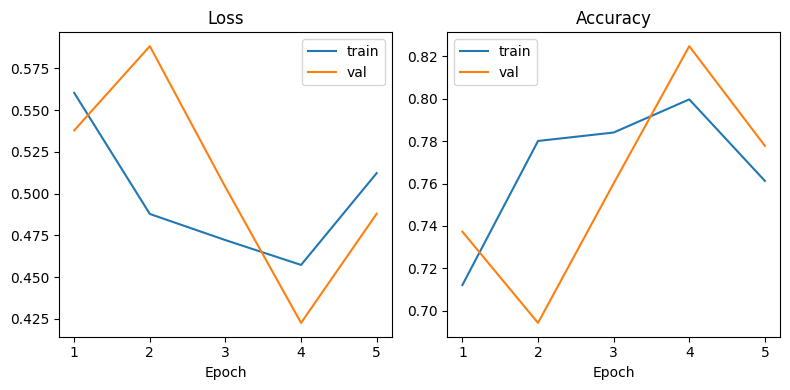

In [2]:
train_loader, val_loader, test_loader = get_dataloaders(
    "lstm", batch_size=config.BATCH_SIZE_LSTM
)
model = AudioLSTMDetector()
trainer = ModelTrainer(model, device=device, model_name="lstm")
history = trainer.train_lstm_detector(
    train_loader, val_loader, epochs=config.EPOCHS_LSTM
)
plot_training_history(history)

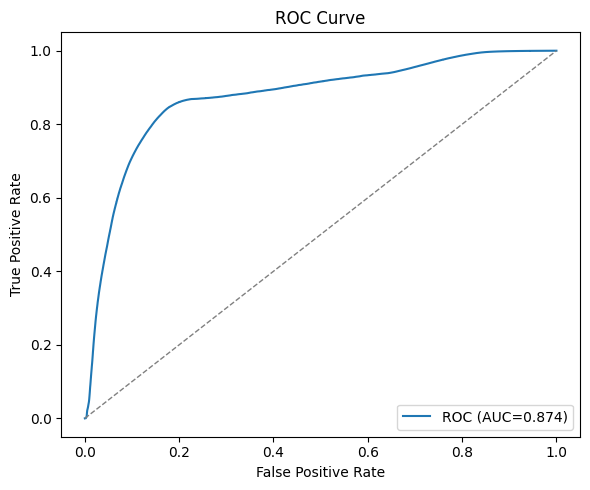

Test ROC AUC: 0.8735


In [3]:
y_true, y_score = trainer.predict_lstm_scores(test_loader)
auc_value = plot_roc_curve(y_true, y_score)
print(f"Test ROC AUC: {auc_value:.4f}")

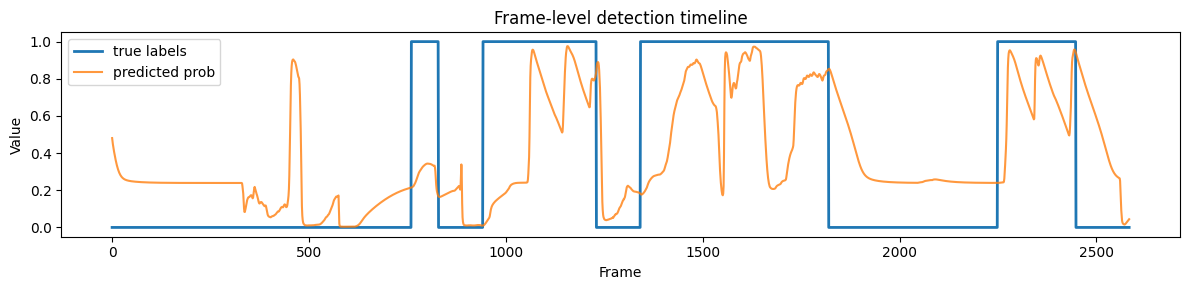

In [4]:
# Visual timeline example for one sequence
mels, labels = next(iter(test_loader))
with torch.no_grad():
    logits = trainer.model(mels.to(device)).squeeze(-1).cpu()
probs = torch.sigmoid(logits)

frame = 0
plt.figure(figsize=(12, 3))
plt.plot(labels[frame].numpy(), label="true labels", linewidth=2)
plt.plot(probs[frame].numpy(), label="predicted prob", alpha=0.8)
plt.title("Frame-level detection timeline")
plt.xlabel("Frame")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
from pathlib import Path

from src.data.dataloaders import export_lstm_debug_samples, load_manifest, fold_split

records = load_manifest()
train_records, _, _ = fold_split(records)
out_dir = Path("data/processed/lstm_debug")
paths = export_lstm_debug_samples(train_records, out_dir=out_dir, n_samples=5)

print(f"Saved {len(paths)} files to: {out_dir.resolve()}")
for p in paths:
    print(" -", p)

print("\nEach sample has companion files:")
print("  *.labels.pt  -> frame-level binary labels")
print("  *.json       -> bird segment timings in seconds")

Saved 5 files to: C:\Users\ekurm\projects\nature-sound-generator\notebooks\data\processed\lstm_debug
 - data\processed\lstm_debug\sample_000.wav
 - data\processed\lstm_debug\sample_001.wav
 - data\processed\lstm_debug\sample_002.wav
 - data\processed\lstm_debug\sample_003.wav
 - data\processed\lstm_debug\sample_004.wav

Each sample has companion files:
  *.labels.pt  -> frame-level binary labels
  *.json       -> bird segment timings in seconds
